<a href="https://colab.research.google.com/github/thejoshbq/PFC_Self-Admin_Analysis/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PFC Self-Admin Analysis

### Load modules

In [6]:
!pip install matplotlib seaborn tqdm

  Preparing metadata (setup.py) ... done
  Created wheel for utils: filename=utils-1.0.2-py2.py3-none-any.whl size=13906 sha256=6f9c1fa8bc614328a517432d7f934dd7f12ac29fcfd6a6696c27bb5c5deefa20
  Stored in directory: /root/.cache/pip/wheels/b6/a1/81/1036477786ae0e17b522f6f5a838f9bc4288d1016fc5d0e1ec
Successfully built utils


In [11]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/My Drive/PFC Self-Admin Analysis')
from utility import compute_global_limits, process_day_data, plot_day, plot_no_data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import os
import zipfile

drive_path = '/content/drive/My Drive/PFC Self-Admin Analysis'
db_path = '/content/drive/My Drive/PFC-Analysis/PFC_Self-Admin.db'
output_dir = os.path.dirname(db_path)

zip_path = os.path.join(drive_path, 'PFC_Self-Admin.zip')
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(output_dir)

['requirements.txt', 'PFC_Self-Admin.zip', 'utils.py', 'analysis.ipynb']


NameError: name 'dp_path' is not defined

In [12]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

### Initialize database and extract data

Initializing database...


Plotting data: 100%|██████████| 8/8 [01:50<00:00, 13.81s/it]


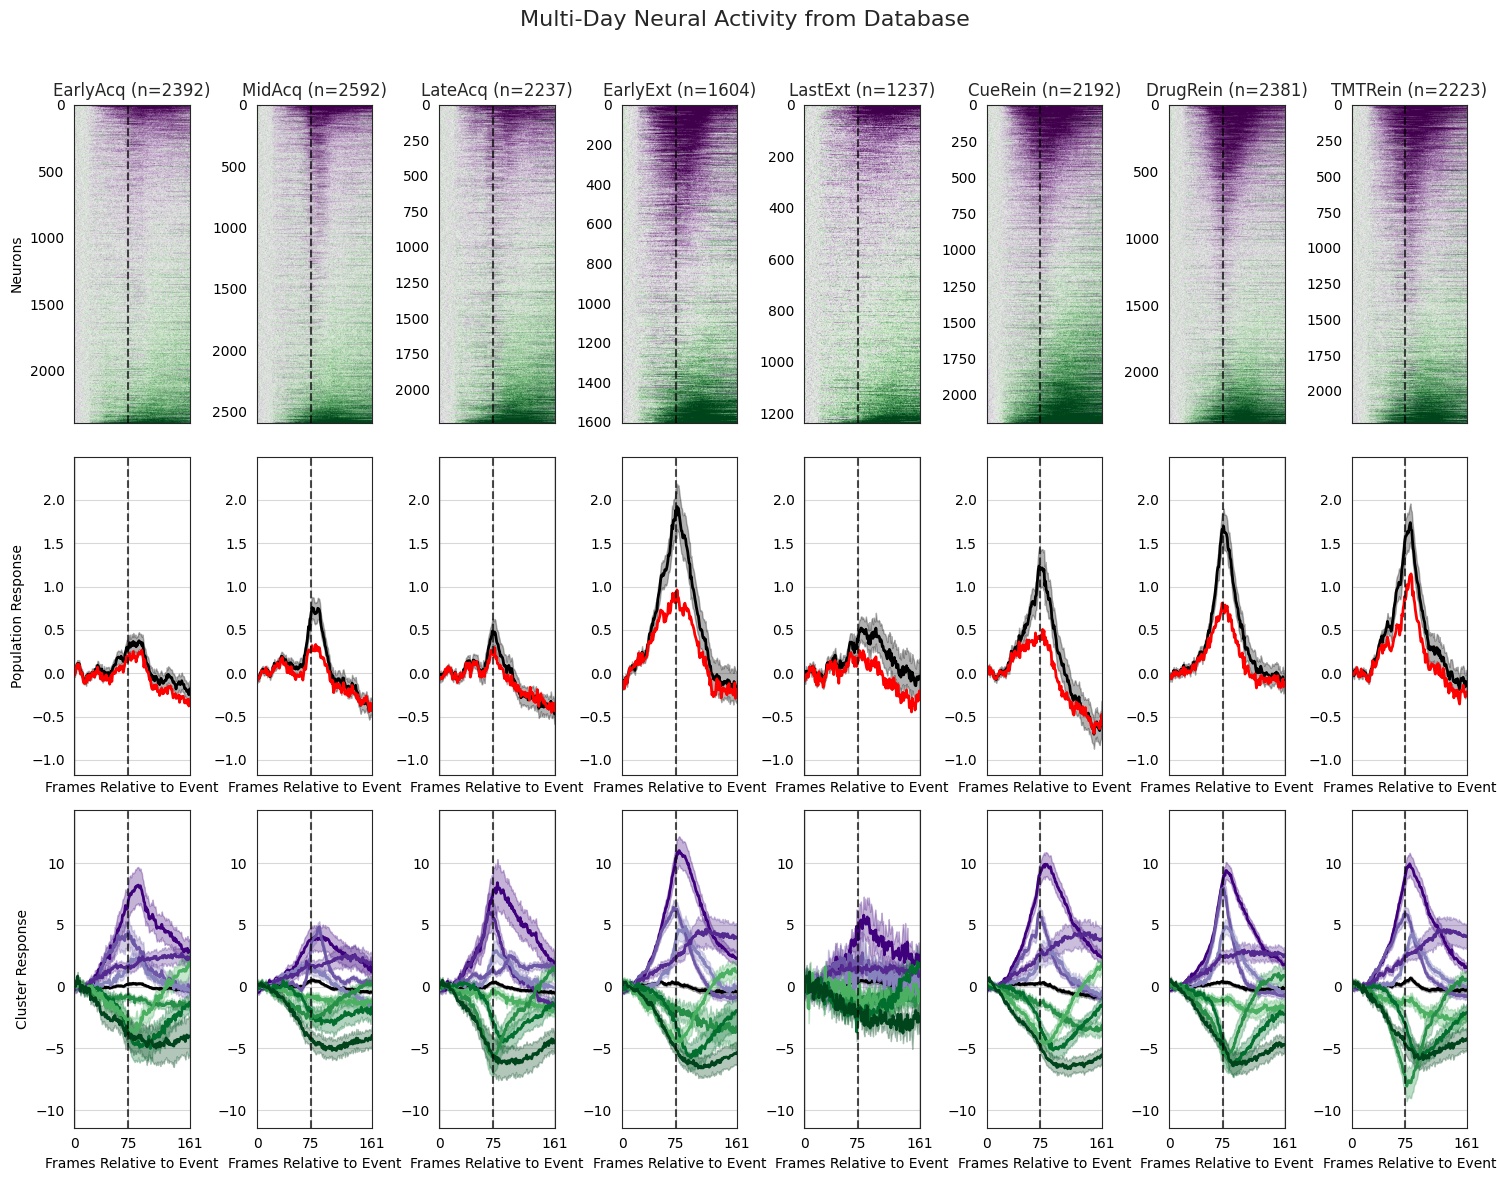

Closing database connection...


In [13]:
print("Initializing database...")
conn = sqlite3.connect(db_path)

try:
    days_df = pd.read_sql_query("SELECT day_id, label FROM Days ORDER BY label", conn)
    days = days_df['label'].tolist()
    day_ids = days_df['day_id'].tolist()
    num_days = len(days)

    if num_days == 0:
        print("No days found in database.")
        exit()

    pop_ylim, cluster_ylim = compute_global_limits(conn, day_ids)

    sns.set_style('white')
    fig, axes = plt.subplots(3, num_days, figsize=(15, 12), sharex='col', squeeze=False)
    fig.suptitle("Multi-Day Neural Activity from Database\n\n", fontsize=16)

    for idx, (did, day) in enumerate(tqdm(zip(day_ids, days), total=num_days, desc="Plotting data")):
        sorted_temp, cluster_data, pop_data, num_valid_neurons = process_day_data(conn, did)

        if num_valid_neurons == 0:
            plot_no_data(axes, day, pop_ylim, cluster_ylim, idx)
            continue

        plot_day(
            axes[0, idx], axes[1, idx], axes[2, idx],
            sorted_temp, cluster_data, pop_data, num_valid_neurons,
            day, pop_ylim, cluster_ylim, idx
        )

    plt.tight_layout()
    plt.show()

finally:
    print("Closing database connection...")
    conn.close()